In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [96]:
data=pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\Machine Learning\0.Data\LR_data.csv')

In [97]:
x_train=data['YearsExperience'].values
y_train=data['Salary'].values

In [98]:
x_train

array([ 1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,  5.5,  6. ,
        6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5])

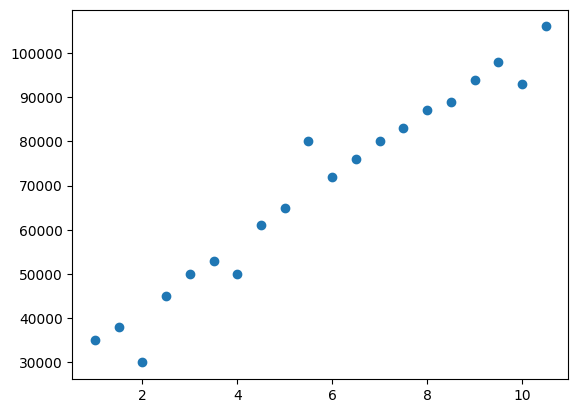

In [99]:
plt.scatter(x_train,y_train)
plt.show()

In [100]:
def cost_func(x,y,w,b):
   m=len(x)
   cost_sum=0

   for i in range(m):
      f=w*x[i]+b    #y=mx+c predicted value
      cost=(f-y[i])**2 #MSE=(y'-yi)^2
      cost_sum+=cost   # MSE=∑(y'-yi)^2
    
   MSE=(1/(2*m))*cost_sum
   return MSE

In [101]:
#gradient function
# dc(w,b)/dw= (1/m)∑xi((w*xi +b)-yi)
# dc(w,b)/db= (1/m)∑((w*xi +b)-yi)

def gradient_func(x,y,w,b):
    m=len(x)
    dc_dw=0 #derivative dc wrt dw
    dc_db=0 # derivative dc wrt db

    for i in range(m):
        f=w*x[i]+b
        dc_dw+= x[i]*(f-y[i])
        dc_db+=(f-y[i])
    
    dc_dw=(1/m)*dc_dw 
    dc_db=(1/m)*dc_db

    return dc_dw,dc_db

In [102]:
#gradient decent
# w= w - α * dc_dw
# b= b - α * dc_db

def gradient_descent(x,y,alpha,iteration):
    w=0
    b=0
    
    for i in range(iteration):
        dc_dw,dc_db=gradient_func(x,y,w,b)

        w = w - alpha*dc_dw
        b = b - alpha*dc_db

        print(f'iteration {i} cost value :{cost_func(x,y,w,b)}')
    
    return w,b

In [103]:
learning_rate=0.01
iterations=1000

final_w,final_b=gradient_descent(x_train,y_train,learning_rate,iterations)
print(f"w:{final_w} b:{final_b}")

iteration 0 cost value :930226590.8242188
iteration 1 cost value :356647762.0225956
iteration 2 cost value :164724413.47339946
iteration 3 cost value :100404100.54886425
iteration 4 cost value :78747100.72267145
iteration 5 cost value :71354723.0344501
iteration 6 cost value :68732166.26000102
iteration 7 cost value :67704942.71750507
iteration 8 cost value :67211694.0306848
iteration 9 cost value :66897564.03564632
iteration 10 cost value :66643908.04295961
iteration 11 cost value :66411056.15475731
iteration 12 cost value :66185742.859945595
iteration 13 cost value :65963530.68107577
iteration 14 cost value :65742933.70845443
iteration 15 cost value :65523452.866531484
iteration 16 cost value :65304919.02617623
iteration 17 cost value :65087273.38125036
iteration 18 cost value :64870494.01982719
iteration 19 cost value :64654571.37402809
iteration 20 cost value :64439500.01190311
iteration 21 cost value :64225275.89309879
iteration 22 cost value :64011895.45128564
iteration 23 cost v

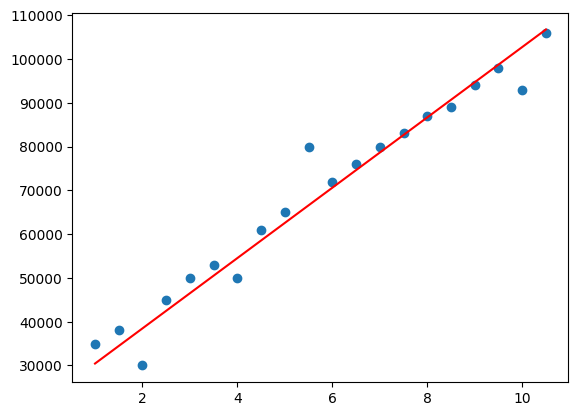

In [104]:
plt.scatter(x_train,y_train)
y_pred= final_w * x_train + final_b
plt.plot(x_train,y_pred,color='red')
plt.show()

# Evaluation

In [105]:
from sklearn.metrics import r2_score

In [106]:
r2_score(y_train,y_pred)*100

95.48362774079642

# SKLearn comparision

In [107]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [108]:
x=data[['YearsExperience']]
y=data['Salary']

In [109]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [110]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [111]:
r2_score(y_test,model.predict(x_test))*100

99.56561846521133